# **Practice Transfer Learning (Feature Extraction)**

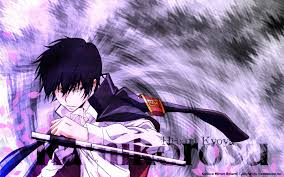

#### 🛠 Exercises

1. Build and fit a model using the same data we have here but with the MobileNetV2 architecture feature extraction ([`mobilenet_v2_100_224/feature_vector`](https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4)) from TensorFlow Hub, how does it perform compared to our other models?

---

2. Name 3 different image classification models on TensorFlow Hub that we haven't used.

---

3. Build a model to classify images of two different things you've taken photos of.
  * You can use any feature extraction layer from TensorFlow Hub you like for this.
  * You should aim to have at least 10 images of each class, for example to build a fridge versus oven classifier, you'll want 10 images of fridges and 10 images of ovens.

---

4. What is the current best performing model on ImageNet?
  * Hint: you might want to check [sotabench.com](https://www.sotabench.com) for this.

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers

In [3]:
# Are we using a GPU?
!nvidia-smi

Sat Feb 14 05:10:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import zipfile

# Download 10% data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# unzip

zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2026-02-14 05:11:44--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.101.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.101.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   169MB/s    in 1.0s    

2026-02-14 05:11:45 (169 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [5]:
# How many images in each folder?
import os

# Walk through 10 percent data directory and list number of files
for dirpath, dirnames, filenames in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/c

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1/255)
test_datagen = ImageDataGenerator(rescale=1/255)

In [8]:
# Generate Training Images:
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                          target_size=IMAGE_SHAPE,
                                                          batch_size=BATCH_SIZE,
                                                          class_mode="categorical")
# Generate Testing Images:
test_data_10_percent = test_datagen.flow_from_directory(test_dir,
                                                        target_size=IMAGE_SHAPE,
                                                        batch_size=BATCH_SIZE,
                                                        class_mode="categorical")

Found 750 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


In [9]:
# Pre-trained model

mobile_net_url = 'https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/100-224-feature-vector/1'

In [14]:
# create a model

def create_model(model_url, num_classes=10):
  feature_extraction_layer = hub.KerasLayer(model_url, trainable=False,
                                            name='feature_extraction_layer',
                                            input_shape=IMAGE_SHAPE+(3,))

  model = tf.keras.Sequential([
      feature_extraction_layer,
      tf.keras.layers.Dense(num_classes, activation='softmax', name='output_layer')
  ])

  return model

In [15]:
train_data_10_percent.num_classes

10

In [16]:
# Bring the transfer learning model - mobilenet

mobilenet_model = create_model(mobile_net_url, num_classes=train_data_10_percent.num_classes)

In [17]:
# Compile

mobilenet_model.compile(loss='categorical_crossentropy',
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['accuracy'])

In [19]:
mobilenet_history = mobilenet_model.fit(train_data_10_percent,
                                  epochs=5,
                                  steps_per_epoch=len(train_data_10_percent),
                                  validation_data=test_data_10_percent,
                                  validation_steps=len(test_data_10_percent))

Epoch 1/5
24/24 [==============================] - 17s 457ms/step - loss: 2.0027 - accuracy: 0.3373 - val_loss: 1.3347 - val_accuracy: 0.5988
Epoch 2/5
24/24 [==============================] - 11s 468ms/step - loss: 1.0588 - accuracy: 0.6867 - val_loss: 0.9076 - val_accuracy: 0.7316
Epoch 3/5
24/24 [==============================] - 9s 366ms/step - loss: 0.7374 - accuracy: 0.7960 - val_loss: 0.7518 - val_accuracy: 0.7792
Epoch 4/5
24/24 [==============================] - 9s 392ms/step - loss: 0.5809 - accuracy: 0.8560 - val_loss: 0.6790 - val_accuracy: 0.7960
Epoch 5/5
24/24 [==============================] - 12s 524ms/step - loss: 0.4815 - accuracy: 0.8840 - val_loss: 0.6526 - val_accuracy: 0.8004


In [20]:
# If you wanted to, you could really turn this into a helper function to load in with a helper.py script...
import matplotlib.pyplot as plt

# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

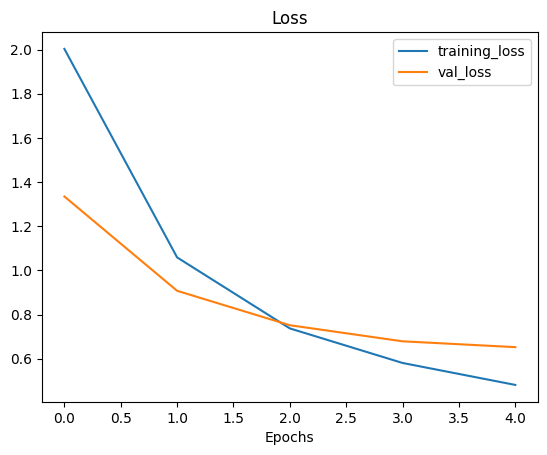

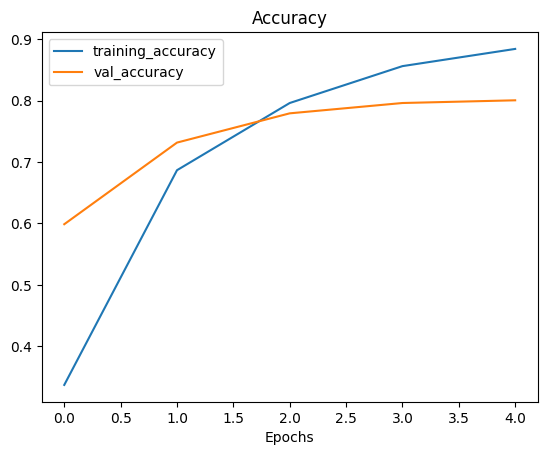

In [21]:
plot_loss_curves(mobilenet_history)

In [22]:
mobilenet_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1280)              2257984   
 KerasLayer)                                                     
                                                                 
 output_layer (Dense)        (None, 10)                12810     
                                                                 
Total params: 2270794 (8.66 MB)
Trainable params: 12810 (50.04 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


> MobileNet is slightly better than ResNet. But not compartable to EfficientNet.

---

# Image Classification Models we haven't used for transfer learning

1️⃣ InceptionV3

- https://tfhub.dev/google/imagenet/inception_v3/feature_vector/5

2️⃣ DenseNet-121

- https://tfhub.dev/google/imagenet/densenet121/feature_vector/5


3️⃣ NASNetLarge

- https://tfhub.dev/google/imagenet/nasnet_large/feature_vector/5


---


According to recent benchmarks on leaderboards like Sotabench and other measurement aggregators:


### 🏆 **Top Performing ImageNet Models**

- CoCa (Contrastive Captioners) variants – e.g., CoCa achieves ~91%+ top-1 accuracy on ImageNet after fine-tuning, making it among the highest-scoring image classification models with very large transformer-based architectures.

- ViTAE-H and Model Soups / ViT-G/14 ensembles – extremely large transformer models also exceed ~90% top-1 accuracy in recent benchmarks.


Some very large vision transformer (ViT) models with weight averaging (“model soups”) also rank at the top of state-of-the-art lists.

On traditional ImageNet-1K evaluations, large pre-trained models like these currently sit near or above 90 % top-1 accuracy, outperforming older top-performers like Big Transfer-Large and conventional CNNs.

> 👉 In practice, these top models are very large transformer-based architectures trained on massive datasets and often require substantial compute — so for feature extraction transfer learning you’d typically use smaller pretrained versions (e.g., ViT variants, ConvNeXt, EfficientNetV2) that are realistic for training on moderate hardware

---